In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#Data path to Colab local
import os

LOCAL_ROOT = "/content"

#The original data is downloaded to the local machine.
WIDER_LOCAL = f"{LOCAL_ROOT}/widerface_raw"
WIDER_FACE_LOCAL = f"{LOCAL_ROOT}/widerface_aligned"

# Create a table of contents
!mkdir -p $WIDER_LOCAL $WIDER_FACE_LOCAL

print(f"WIDER data path: {WIDER_LOCAL}")
print(f"Align the output path: {WIDER_FACE_LOCAL}")

WIDER data path: /content/widerface_raw
Align the output path: /content/widerface_aligned


In [ ]:
import os
# If kaggle.json is already in Drive (for example, in the root directory of MyDrive), copy it to ~/.kaggle and configure the permissions.
kaggle_json_path = '/content/drive/MyDrive/kaggle.json'
if os.path.exists(kaggle_json_path):
    !mkdir -p ~/.kaggle
    !cp /content/drive/MyDrive/kaggle.json ~/.kaggle/
    !chmod 600 ~/.kaggle/kaggle.json
else:
    print("Please provide the Kaggle API credentials kaggle.json")

In [ ]:
!pip install -U insightface onnxruntime onnx opencv-python --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 439.5/439.5 kB 11.7 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.4/17.4 MB 108.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 125.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 9.4 MB/s eta 0:00:00


In [ ]:
#Download WIDER FACE to Colab local storage
import os

# check
if not os.path.exists(f"{WIDER_LOCAL}/WIDER_train/WIDER_train/images"):
    print("Download WIDER FACE to Colab local storage")
    !kaggle datasets download -d mksaad/wider-face-a-face-detection-benchmark -p "$WIDER_LOCAL"
    !unzip -q "$WIDER_LOCAL/wider-face-a-face-detection-benchmark.zip" -d "$WIDER_LOCAL"
    print("Download completed！")
else:
    print("WIDER FACE already exists locally in Colab")

Download WIDER FACE to Colab local storage
Dataset URL: https://www.kaggle.com/datasets/mksaad/wider-face-a-face-detection-benchmark
License(s): unknown
 99% 3.38G/3.41G [00:27<00:00, 40.9MB/s]
100% 3.41G/3.41G [00:27<00:00, 132MB/s] 
Download completed！


Display the first 5 images:
1. 0_Parade_marchingband_1_100.jpg - size: (682, 1024, 3)
2. 0_Parade_marchingband_1_1015.jpg - size: (683, 1024, 3)
3. 0_Parade_marchingband_1_1018.jpg - size: (680, 1024, 3)
4. 0_Parade_marchingband_1_1022.jpg - size: (668, 1024, 3)
5. 0_Parade_marchingband_1_1030.jpg - size: (361, 1024, 3)


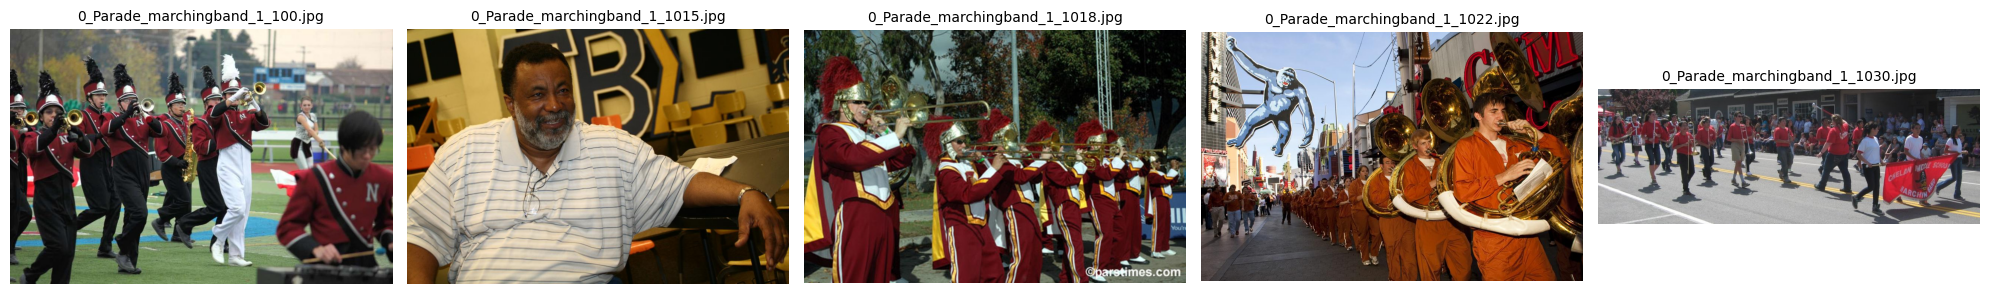

In [ ]:
import cv2
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow

# Get the first 5 image files
image_files = !ls $WIDER_LOCAL/WIDER_train/WIDER_train/images/0--Parade | head -5
image_dir = f"{WIDER_LOCAL}/WIDER_train/WIDER_train/images/0--Parade"

print("Display the first 5 images:")

# Create subgraph display
fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for i, img_file in enumerate(image_files):
    if img_file:  # Ensure the file name is not empty
        img_path = f"{image_dir}/{img_file}"
        img = cv2.imread(img_path)
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Convert to RGB format

        axes[i].imshow(img_rgb)
        axes[i].set_title(f"{img_file}", fontsize=10)
        axes[i].axis('off')

        print(f"{i+1}. {img_file} - size: {img.shape}")

plt.tight_layout()
plt.show()

In [ ]:
import os
import sys
import math
import glob
import subprocess
import onnxruntime as ort
import numpy as np
import cv2
import pandas as pd

try:
    from tqdm.notebook import tqdm
except ImportError:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "tqdm"])
    from tqdm.notebook import tqdm

# install onnxruntime-gpu
subprocess.run(
    [sys.executable, "-m", "pip", "install", "-q",
     "onnxruntime-gpu", "opencv-python", "pandas", "numpy"],
    check=False
)

SPLIT = "WIDER_val" # Define SPLIT here

# Use a local path
DATA_ROOT = f"{WIDER_LOCAL}/{SPLIT}/{SPLIT}/images"
print("WIDER data path：", DATA_ROOT)

# Aligned face output directory (224×224) - also placed locally
ALIGNED_ROOT = f"{WIDER_LOCAL}/{SPLIT}_aligned_224"
os.makedirs(ALIGNED_ROOT, exist_ok=True)
print("Alignment of face output path:", ALIGNED_ROOT)

# RetinaFace ONNX model
onnx_model_path = "retinaface_mobilenet0.25.onnx"

if not os.path.exists(onnx_model_path):
    print("ONNX model not found, starting to download the pre-trained model RetinaFace（mobilenet0.25）...")
    url = "https://huggingface.co/amd/retinaface/resolve/main/weights/RetinaFace_int.onnx"
    subprocess.run(["wget", "-O", onnx_model_path, url], check=True)
else:
    print("find ONNX model:", onnx_model_path)

import onnxruntime as ort

#use CUDA
providers = ["CUDAExecutionProvider"]
session = ort.InferenceSession(onnx_model_path, providers=providers)
prov = session.get_providers()
print("current providers:", prov)

if "CUDAExecutionProvider" not in prov:
    raise RuntimeError(
        "ONNXRuntime is not using the CUDAExecutionProvider, which indicates that the GPU in the current environment is unavailable or there is an issue with the installation of onnxruntime-gpu.\n"
        "Please first confirm that the Runtime Type in Colab is set to GPU, and then reinstall onnxruntime-gpu."
    )

input_name = session.get_inputs()[0].name
input_shape = session.get_inputs()[0].shape  # [N,3,H,W] or [N,H,W,3]

print("ONNX input name:", input_name)
print("ONNX input shape:", input_shape)

# judge NCHW / NHWC
NCHW = False
if len(input_shape) == 4:
    if input_shape[1] == 3:
        NCHW = True   # [N,3,H,W]
    elif input_shape[-1] == 3:
        NCHW = False  # [N,H,W,3]
print("Model input layout:", "NCHW" if NCHW else "NHWC")

# Automatically read H and W from the model's input_shape (your model is like 608×640)
if NCHW:
    INPUT_H = int(input_shape[2])
    INPUT_W = int(input_shape[3])
else:
    INPUT_H = int(input_shape[1])
    INPUT_W = int(input_shape[2])

print("ussed imput size: ", INPUT_H, "x", INPUT_W)
TARGET_SIZE = (INPUT_H, INPUT_W)

WIDER data path： /content/widerface_raw/WIDER_val/WIDER_val/images
Alignment of face output path: /content/widerface_raw/WIDER_val_aligned_224
find ONNX model: retinaface_mobilenet0.25.onnx
current providers: ['CPUExecutionProvider']


RuntimeError: ONNXRuntime is not using the CUDAExecutionProvider, which indicates that the GPU in the current environment is unavailable or there is an issue with the installation of onnxruntime-gpu.
Please first confirm that the Runtime Type in Colab is set to GPU, and then reinstall onnxruntime-gpu.

In [ ]:
#RetinaFace tool function（priors / decode / NMS / align）

cfg = {
    "min_sizes": [[16, 32], [64, 128], [256, 512]],
    "steps": [8, 16, 32],
    "variance": [0.1, 0.2]
}

def generate_priors(image_shape, cfg):
    #Generate the prior boxes (cx, cy, w, h) of RetinaFace according to the input image size, with normalized coordinates.
    #image_shape: (H, W)

    image_h, image_w = image_shape
    priors = []
    for k, step in enumerate(cfg["steps"]):
        feat_h = int(math.ceil(image_h / step))
        feat_w = int(math.ceil(image_w / step))
        min_sizes = cfg["min_sizes"][k]
        for i in range(feat_h):
            for j in range(feat_w):
                cy = (i + 0.5) * step / image_h
                cx = (j + 0.5) * step / image_w
                for min_size in min_sizes:
                    w = min_size / image_w
                    h = min_size / image_h
                    priors.append([cx, cy, w, h])
    priors = np.array(priors, dtype=np.float32)
    return priors

def decode_boxes(loc, priors, variances):
    #loc: [num_priors, 4]
    #priors: [num_priors, 4]  (cx, cy, w, h)
    #return: [num_priors, 4] (x1,y1,x2,y2)，Normalized coordinates
    boxes = np.concatenate((
        priors[:, :2] + loc[:, :2] * variances[0] * priors[:, 2:],
        priors[:, 2:] * np.exp(loc[:, 2:] * variances[1])
    ), axis=1)  # [cx, cy, w, h]

    # cx, cy, w, h -> x1, y1, x2, y2
    boxes[:, :2] -= boxes[:, 2:] / 2.0        # x1 = cx - w/2
    boxes[:, 2:] += boxes[:, :2]             # x2 = x1 + w, y2 = y1 + h
    return boxes


def decode_landmarks(landms, priors, variances):
    #landms: [num_priors, 10]
    #priors: [num_priors, 4]
    #return: [num_priors, 10] (5 key points, each (x, y) normalized)
    out = np.zeros_like(landms)
    for k in range(5):
        out[:, 2 * k:2 * k + 2] = priors[:, :2] + \
            landms[:, 2 * k:2 * k + 2] * variances[0] * priors[:, 2:]
    return out

def nms_numpy(dets, thresh=0.4):
    #dets: [N, 5] -> x1,y1,x2,y2,score
    #Return the list of retained index
    if dets.size == 0:
        return []

    x1 = dets[:, 0]
    y1 = dets[:, 1]
    x2 = dets[:, 2]
    y2 = dets[:, 3]
    scores = dets[:, 4]

    order = scores.argsort()[::-1]
    keep = []

    while order.size > 0:
        i = order[0]
        keep.append(i)

        xx1 = np.maximum(x1[i], x1[order[1:]])
        yy1 = np.maximum(y1[i], y1[order[1:]])
        xx2 = np.minimum(x2[i], x2[order[1:]])
        yy2 = np.minimum(y2[i], y2[order[1:]])

        w = np.maximum(0.0, xx2 - xx1)
        h = np.maximum(0.0, yy2 - yy1)
        inter = w * h
        area_i = (x2[i] - x1[i]) * (y2[i] - y1[i])
        area_j = (x2[order[1:]] - x1[order[1:]]) * (y2[order[1:]] - y1[order[1:]])
        union = area_i + area_j - inter
        ovr = inter / np.maximum(union, 1e-6)

        inds = np.where(ovr <= thresh)[0]
        order = order[inds + 1]

    return keep

def align_face(img, landmarks, output_size=224):
    #Use 5 key points for alignment and crop the face to output_size × output_size。
    #landmarks: [5, 2]，corresponding to l_eye/r_eye/nose_tip/l_mouth/r_mouth
    # 112×112 ArcFace template points
    dst = np.array([
        [38.2946, 51.6963],
        [73.5318, 51.5014],
        [56.0252, 71.7366],
        [41.5493, 92.3655],
        [70.7299, 92.2041],
    ], dtype=np.float32)

    # Zoom to output_size
    scale = output_size / 112.0
    dst *= scale

    src = landmarks.astype(np.float32)

    # Estimate the affine transformation using 5 points
    M, _ = cv2.estimateAffinePartial2D(src, dst, method=cv2.LMEDS)
    if M is None:
        # If it fails, it will degrade to center cropping.
        h, w = img.shape[:2]
        side = min(h, w)
        cx, cy = w // 2, h // 2
        x1 = max(0, cx - side // 2)
        y1 = max(0, cy - side // 2)
        crop = img[y1:y1 + side, x1:x1 + side]
        return cv2.resize(crop, (output_size, output_size))

    aligned = cv2.warpAffine(img, M, (output_size, output_size), borderValue=0)
    return aligned

def preprocess_image(img_path, target_size=(INPUT_H, INPUT_W)):
    #Read an image, scale it proportionally + pad it to the target_size, and subtract the mean value.
    #return：
    #  img_input: [1,3,H,W] or [1,H,W,3]
    #  scale: Scaling ratio
    #  orig_size: (orig_h, orig_w)
    #  orig_img: origin BGR image
    img = cv2.imread(img_path)
    if img is None:
        raise FileNotFoundError(f"image {img_path} not fined")

    orig_h, orig_w = img.shape[:2]
    target_h, target_w = target_size

    # Proportional scaling
    scale = min(target_w / orig_w, target_h / orig_h)
    new_w = int(orig_w * scale)
    new_h = int(orig_h * scale)
    resized = cv2.resize(img, (new_w, new_h))

    # Fill to the target size
    canvas = np.zeros((target_h, target_w, 3), dtype=np.uint8)
    canvas[:new_h, :new_w, :] = resized

    # Subtract the mean
    img_float = canvas.astype(np.float32)
    img_float -= np.array([104, 117, 123], dtype=np.float32)

    if NCHW:
        # [H,W,3] -> [1,3,H,W]
        img_input = np.transpose(img_float, (2, 0, 1))[None, ...]
    else:
        # [H,W,3] -> [1,H,W,3]
        img_input = img_float[None, ...]

    return img_input, scale, (orig_h, orig_w), img

# Generating priors under fixed input size
priors = generate_priors((INPUT_H, INPUT_W), cfg)
num_priors = priors.shape[0]
print("Number of anchor boxes num_priors:", num_priors)


NameError: name 'INPUT_H' is not defined

In [ ]:
# Batch run WIDER + alignment cropping + save CSV
import numpy as np
import pandas as pd
import cv2
import os
import glob
from tqdm.notebook import tqdm

# Re-collect image paths
image_paths = sorted(glob.glob(os.path.join(DATA_ROOT, "*", "*.jpg")))
print(f"Originally found in total {len(image_paths)}")

DEBUG_MAX_IMAGES = None
if DEBUG_MAX_IMAGES is not None:
    image_paths = image_paths[:DEBUG_MAX_IMAGES]
    print(f"Debug mode: only run the first part {len(image_paths)} ")

batch_size = 8
conf_thresh = 0.6        # Confidence threshold
nms_thresh = 0.4
aligned_size = 224       # output 224×224

all_records = []
mismatch_warned = False

for i in tqdm(range(0, len(image_paths), batch_size), desc="RetinaFace-ONNX Stage0"):
    batch_paths = image_paths[i:i + batch_size]

    batch_inputs = []
    batch_scales = []
    batch_orig_sizes = []
    batch_original_imgs = []

    # Preprocess all images in the batch
    for p in batch_paths:
        img_input, scale, orig_size, orig_img = preprocess_image(p, TARGET_SIZE)
        batch_inputs.append(img_input)
        batch_scales.append(scale)
        batch_orig_sizes.append(orig_size)
        batch_original_imgs.append(orig_img)

    batch_input = np.vstack(batch_inputs).astype(np.float32)

    # ONNX Reasoning：loc, conf, landms
    loc_batch, conf_batch, landms_batch = session.run(
        None, {input_name: batch_input}
    )

    for b, img_path in enumerate(batch_paths):
        loc = loc_batch[b]
        conf = conf_batch[b]
        landms = landms_batch[b]

        #Unified reshape & automatic alignment of anchor quantity
        loc = np.array(loc).reshape(-1, 4)
        conf = np.array(conf).reshape(-1, 2)
        landms = np.array(landms).reshape(-1, 10)

        num_loc = loc.shape[0]
        num_conf = conf.shape[0]
        num_land = landms.shape[0]
        num_prior = priors.shape[0]

        #Take the smallest one to prevent inconsistent output dimensions of one of them.
        num = min(num_loc, num_conf, num_land, num_prior)

        if not mismatch_warned and len({num_loc, num_conf, num_land, num_prior}) != 1:
            print(" anchor Inconsistent quantities:",
                  f"loc={num_loc}, conf={num_conf}, landms={num_land}, priors={num_prior}",
                  "，Automatically intercepted as", num)
            mismatch_warned = True

        loc = loc[:num]
        conf = conf[:num]
        landms = landms[:num]
        priors_use = priors[:num]

        #Apply softmax to conf to get the real score
        conf_exp = np.exp(conf - np.max(conf, axis=-1, keepdims=True))
        conf_softmax = conf_exp / np.sum(conf_exp, axis=-1, keepdims=True)
        scores = conf_softmax[:, 1]  # catogry 1 = face

        # Threshold filtering
        keep = scores > conf_thresh
        if not np.any(keep):
            continue

        loc = loc[keep]
        scores_keep = scores[keep]
        landms_keep = landms[keep]
        priors_keep = priors_use[keep]

        # decoding boxes and landmarks
        boxes = decode_boxes(loc, priors_keep, cfg["variance"])
        landms_dec = decode_landmarks(landms_keep, priors_keep, cfg["variance"])

        # Normalization -> Input size coordinates
        boxes[:, 0::2] *= INPUT_W
        boxes[:, 1::2] *= INPUT_H
        landms_dec[:, 0::2] *= INPUT_W
        landms_dec[:, 1::2] *= INPUT_H

        # Map back to the original image coordinates
        scale = batch_scales[b]
        orig_h, orig_w = batch_orig_sizes[b]
        boxes[:, 0::2] /= scale
        boxes[:, 1::2] /= scale
        landms_dec[:, 0::2] /= scale
        landms_dec[:, 1::2] /= scale

        # The cropping is within the image range.
        boxes[:, 0::2] = np.clip(boxes[:, 0::2], 0, orig_w - 1)
        boxes[:, 1::2] = np.clip(boxes[:, 1::2], 0, orig_h - 1)

        # NMS
        dets_for_nms = np.hstack([boxes, scores_keep[:, None]]).astype(np.float32)
        keep_indices = nms_numpy(dets_for_nms, thresh=nms_thresh)

        boxes = boxes[keep_indices]
        scores_final = scores_keep[keep_indices]
        landms_dec = landms_dec[keep_indices]

        # Align + Save Face
        orig_img = batch_original_imgs[b]
        rel_path = os.path.relpath(img_path, DATA_ROOT)  # as 0--Parade/0_xxx.jpg
        rel_dir, img_name = os.path.split(rel_path)
        save_dir = os.path.join(ALIGNED_ROOT, rel_dir)
        os.makedirs(save_dir, exist_ok=True)

        for j in range(boxes.shape[0]):
            x1, y1, x2, y2 = boxes[j]
            s = float(scores_final[j])
            lm = landms_dec[j].reshape(5, 2)

            aligned_face = align_face(orig_img, lm, output_size=aligned_size)

            face_filename = os.path.splitext(img_name)[0] + f"_face{j:02d}.jpg"
            face_path = os.path.join(save_dir, face_filename)
            cv2.imwrite(face_path, aligned_face)

            record = {
                "image": img_path,
                "face_path": face_path,
                "x1": float(x1),
                "y1": float(y1),
                "x2": float(x2),
                "y2": float(y2),
                "score": s,
                "left_eye_x": float(lm[0, 0]), "left_eye_y": float(lm[0, 1]),
                "right_eye_x": float(lm[1, 0]), "right_eye_y": float(lm[1, 1]),
                "nose_x": float(lm[2, 0]), "nose_y": float(lm[2, 1]),
                "mouth_left_x": float(lm[3, 0]), "mouth_left_y": float(lm[3, 1]),
                "mouth_right_x": float(lm[4, 0]), "mouth_right_y": float(lm[4, 1]),
            }
            all_records.append(record)

# save CSV
out_csv = f"retinaface_onnx_{SPLIT}_aligned224_detections.csv"
df = pd.DataFrame(all_records)
df.to_csv(out_csv, index=False, float_format="%.3f")
print(f"Stage0Complete detection + alignment，all {len(df)} faces，CSV: {out_csv}")
print("Align the face sample directory:", ALIGNED_ROOT)
df.head()


Originally found in total 3226


RetinaFace-ONNX Stage0:   0%|          | 0/404 [00:00<?, ?it/s]

Stage0Complete detection + alignment，all 13624 faces，CSV: retinaface_onnx_WIDER_val_aligned224_detections.csv
Align the face sample directory: /content/widerface_raw/WIDER_val_aligned_224


,image,face_path,x1,y1,x2,y2,score,left_eye_x,left_eye_y,right_eye_x,right_eye_y,nose_x,nose_y,mouth_left_x,mouth_left_y,mouth_right_x,mouth_right_y
0,/content/widerface_raw/WIDER_val/WIDER_val/ima...,/content/widerface_raw/WIDER_val_aligned_224/0...,595.280273,520.799011,616.239807,546.721008,0.969785,602.239990,530.240051,610.880005,530.559937,607.039978,536.000000,602.880005,540.799988,609.280029,541.119995
1,/content/widerface_raw/WIDER_val/WIDER_val/ima...,/content/widerface_raw/WIDER_val_aligned_224/0...,185.151642,534.535522,203.648346,558.584534,0.956634,189.439987,544.320007,197.439987,544.320007,192.959991,549.760010,190.399994,553.919983,197.119995,553.919983
2,/content/widerface_raw/WIDER_val/WIDER_val/ima...,/content/widerface_raw/WIDER_val_aligned_224/0...,523.358276,535.836060,542.561768,560.804016,0.851953,528.640015,546.560059,536.320007,546.560059,531.840027,551.680054,529.280029,555.839966,535.040039,555.839966
3,/content/widerface_raw/WIDER_val/WIDER_val/ima...,/content/widerface_raw/WIDER_val_aligned_224/0...,330.058777,543.637573,345.781281,562.602478,0.787931,334.080017,551.039978,341.120026,551.359985,337.600006,554.880005,335.040009,558.400024,340.480011,558.400024
4,/content/widerface_raw/WIDER_val/WIDER_val/ima...,/content/widerface_raw/WIDER_val_aligned_224/0...,658.399841,525.760010,680.160278,551.359985,0.782663,663.359985,534.400024,672.320007,534.720032,666.880005,540.160034,664.000000,544.959961,671.039978,544.959961


In [ ]:
import os
import numpy as np
import pandas as pd


#lode WIDER label
def load_wider_annotations(txt_path):
    #Analysis wider_face_*_bbx_gt.txt
    #return: gt_dict[relative_img_path] = ndarray [num_faces, 4] (x1,y1,x2,y2)
    gt_dict = {}
    with open(txt_path, "r") as f:
        lines = f.read().strip().splitlines()

    i = 0
    while i < len(lines):
        img_rel = lines[i].strip()      # as 0--Parade/0_Parade_marchingband_1_100.jpg
        i += 1
        num_faces = int(lines[i].strip())
        i += 1
        boxes = []
        for _ in range(num_faces):
            parts = lines[i].strip().split()
            i += 1
            if len(parts) < 4:
                continue
            x1 = int(parts[0])
            y1 = int(parts[1])
            w  = int(parts[2])
            h  = int(parts[3])
            if w <= 0 or h <= 0:
                continue
            x2 = x1 + w
            y2 = y1 + h
            boxes.append([x1, y1, x2, y2])
        if len(boxes) > 0:
            gt_dict[img_rel] = np.array(boxes, dtype=np.float32)
        else:
            gt_dict[img_rel] = np.zeros((0, 4), dtype=np.float32)
    return gt_dict

def iou(box, boxes):
    #box: [4]
    #boxes: [N,4]
    if boxes.size == 0:
        return np.zeros((0,), dtype=np.float32)
    x1 = np.maximum(box[0], boxes[:, 0])
    y1 = np.maximum(box[1], boxes[:, 1])
    x2 = np.minimum(box[2], boxes[:, 2])
    y2 = np.minimum(box[3], boxes[:, 3])
    w = np.maximum(0.0, x2 - x1)
    h = np.maximum(0.0, y2 - y1)
    inter = w * h
    area1 = (box[2] - box[0]) * (box[3] - box[1])
    area2 = (boxes[:, 2] - boxes[:, 0]) * (boxes[:, 3] - boxes[:, 1])
    return inter / np.maximum(area1 + area2 - inter, 1e-6)

# Load the detection results output by Stage0 ONNX
SPLIT = "WIDER_val"

#Use the CSV that exist in
det_csv = f"/content/retinaface_onnx_{SPLIT}_aligned224_detections.csv"
df_det = pd.read_csv(det_csv)
print(f"Read the detection results: {det_csv}, {len(df_det)} prediction box")

#Change the absolute path to a relative path (aligned with the keys in wider_face_val_bbx_gt.txt)
def path_to_rel(p):
    key = f"{SPLIT}/{SPLIT}/images/"
    p = str(p).replace("\\", "/")
    idx = p.find(key)
    if idx >= 0:
        return p[idx + len(key):]
    # Bottom line: the last two levels of directories
    return "/".join(p.split("/")[-2:])

df_det["rel_path"] = df_det["image"].astype(str).apply(path_to_rel)

# Each picture corresponds to a bunch of (box, score)
pred_by_img = {}
for _, row in df_det.iterrows():
    rp = row["rel_path"]
    box = np.array([row["x1"], row["y1"], row["x2"], row["y2"]], dtype=np.float32)
    score = float(row["score"])
    pred_by_img.setdefault(rp, []).append((box, score))

#Load the GT and calculate AP@0.5
gt_txt = os.path.join(
    WIDER_ROOT,
    "wider_face_split",
    "wider_face_split",
    "wider_face_val_bbx_gt.txt"
)
gt_dict = load_wider_annotations(gt_txt)
print("GT number of images:", len(gt_dict))

all_gt_boxes = []
gt_img_start_idx = {}
current_gt_idx = 0
for img_rel, boxes in gt_dict.items():
    n = boxes.shape[0]
    gt_img_start_idx[img_rel] = (current_gt_idx, current_gt_idx + n)
    all_gt_boxes.append(boxes)
    current_gt_idx += n

all_gt_boxes = np.concatenate(all_gt_boxes, axis=0)
num_gt = all_gt_boxes.shape[0]
print("Total GT face count:", num_gt)

# Flatten all predictions
img_rel_list = list(gt_dict.keys())
img_idx_map = {rel: idx for idx, rel in enumerate(img_rel_list)}

all_pred_boxes = []
all_pred_scores = []
all_pred_img_idx = []

for img_rel, preds in pred_by_img.items():
    if img_rel not in img_idx_map:
        continue
    img_idx = img_idx_map[img_rel]
    for box, score in preds:
        all_pred_boxes.append(box)
        all_pred_scores.append(score)
        all_pred_img_idx.append(img_idx)

if len(all_pred_boxes) == 0:
    raise RuntimeError("The detection result is empty. It may be that the conf_thresh is set too high or the CSV path is incorrect.")

all_pred_boxes = np.stack(all_pred_boxes, axis=0)
all_pred_scores = np.array(all_pred_scores, dtype=np.float32)
all_pred_img_idx = np.array(all_pred_img_idx, dtype=np.int32)

#Sort in descending order by score
order = np.argsort(-all_pred_scores)
all_pred_boxes = all_pred_boxes[order]
all_pred_scores = all_pred_scores[order]
all_pred_img_idx = all_pred_img_idx[order]

#Match each prediction box with the ground truth (GT) one by one, and calculate true positives (TP) and false positives (FP)
gt_matched = np.zeros((num_gt,), dtype=bool)
tp = np.zeros((len(all_pred_boxes),), dtype=np.float32)
fp = np.zeros((len(all_pred_boxes),), dtype=np.float32)

iou_thresh = 0.5

for i, (box, img_idx) in enumerate(zip(all_pred_boxes, all_pred_img_idx)):
    img_rel = img_rel_list[img_idx]
    start, end = gt_img_start_idx[img_rel]
    gt_boxes_img = all_gt_boxes[start:end]
    if gt_boxes_img.shape[0] == 0:
        fp[i] = 1.0
        continue

    ious = iou(box, gt_boxes_img)
    max_iou = np.max(ious)
    max_idx_local = np.argmax(ious)
    max_idx = start + max_idx_local

    if max_iou >= iou_thresh and not gt_matched[max_idx]:
        tp[i] = 1.0
        gt_matched[max_idx] = True
    else:
        fp[i] = 1.0

tp_cum = np.cumsum(tp)
fp_cum = np.cumsum(fp)
recall = tp_cum / max(float(num_gt), 1.0)
precision = tp_cum / np.maximum(tp_cum + fp_cum, 1e-6)

#Calculate VOC style AP
def voc_ap(rec, prec):
    mrec = np.concatenate(([0.0], rec, [1.0]))
    mpre = np.concatenate(([0.0], prec, [0.0]))
    # Take envelope from the back to the front
    for i in range(mpre.size - 1, 0, -1):
        mpre[i - 1] = np.maximum(mpre[i - 1], mpre[i])
    idx = np.where(mrec[1:] != mrec[:-1])[0]
    ap = np.sum((mrec[idx + 1] - mrec[idx]) * mpre[idx + 1])
    return ap

ap50 = voc_ap(recall, precision)

overall_recall = tp_cum[-1] / max(float(num_gt), 1.0)
overall_precision = tp_cum[-1] / max(float(tp_cum[-1] + fp_cum[-1]), 1e-6)
f1 = 2 * overall_precision * overall_recall / max(overall_precision + overall_recall, 1e-6)

print("\n===== Evaluation of the WIDER FACE validation set (RetinaFace ONNX Stage0) =====")
print(f"IoU threshold:       {iou_thresh}")
print(f"GT Number of faces:      {num_gt}")
print(f"Number of prediction boxes:     {len(all_pred_boxes)}")
print(f"total Recall:    {overall_recall:.4f}")
print(f"total Precision: {overall_precision:.4f}")
print(f"F1-score:       {f1:.4f}")
print(f"AP@0.5 (approx):{ap50:.4f}")


读取检测结果: /content/retinaface_onnx_WIDER_val_aligned224_detections.csv, 共 13624 条预测框
GT 图像数量: 3226
总 GT 人脸数: 39697

===== WIDER FACE 验证集评估 (RetinaFace ONNX Stage0) =====
IoU 阈值:       0.5
GT 人脸数:      39697
预测框数量:     13624
整体 Recall:    0.3115
整体 Precision: 0.9077
F1-score:       0.4638
AP@0.5 (approx):0.3066


In [ ]:
#After processing, save the results to Google Drive.

import shutil
from google.colab import drive

# Define the save path on Google Drive
DRIVE_RESULTS_DIR = f"/content/drive/MyDrive/ColabData/widerface_results"

# Create a table of contents
!mkdir -p $DRIVE_RESULTS_DIR

print("Save the result to Google Drive...")

#copy CSV
csv_files = [f for f in os.listdir(".") if f.endswith(".csv")]
for csv_file in csv_files:
    shutil.copy(csv_file, f"{DRIVE_RESULTS_DIR}/{csv_file}")
    print(f"✅ 已保存: {csv_file}")

#copy ONNX
if os.path.exists("retinaface_mobilenet0.25.onnx"):
    shutil.copy("retinaface_mobilenet0.25.onnx", f"{DRIVE_RESULTS_DIR}/retinaface_mobilenet0.25.onnx")

print("All results have been saved to Google Drive!")
print(f"Google Drive path: {DRIVE_RESULTS_DIR}")